# E-Commerce Customer Churn — Full Analysis
### From raw data to business answers, explained step-by-step for beginners

**How to use this notebook:** Open it in Google Colab, click *Runtime → Run all*, and when prompted, upload your e-commerce Excel file. That's the only manual step — everything else (cleaning, charts, models, results) runs automatically and stays in memory; no folders, PNGs, or CSVs need to be created or uploaded separately.

This notebook works through **one real e-commerce dataset** (5,630 customers, 20 columns) to answer four business questions using data science:

1. **Which active customers are most likely to churn (leave) in the next 30 days, and what behaviours signal it?**
2. **Which customers buy mainly because of cashback/coupons, and which stay loyal without heavy discounting?**
3. **Can we predict a customer complaint before it happens, using recent activity?**
4. **At what delivery-distance threshold does friction start driving up complaints and churn, and does this differ by region (city tier)?**

We'll follow the standard data science workflow used in industry, called **CRISP-DM**:

| Step | What it means in plain English |
|---|---|
| 1. Business Understanding | Already done above — we know the 4 questions we must answer |
| 2. Data Understanding | Look at the raw data: what columns exist, what's missing, what's weird |
| 3. Data Preparation | Clean the data so a computer algorithm can use it |
| 4. Exploratory Data Analysis (EDA) | Look for patterns and relationships with charts |
| 5. Modeling | Train Machine Learning (ML) models that learn patterns from data |
| 6. Evaluation | Check how good the models actually are, in numbers that mean something |
| 7. Business Answers | Translate model results back into plain-English recommendations |

**No prior ML experience required** — every technical term is explained the first time it's used.


## Step 1 — Load the libraries and the data

We start by importing the Python "toolboxes" (libraries) we need:
- **pandas** — for working with tables of data (like Excel, but in code)
- **numpy** — for numerical operations
- **matplotlib / seaborn** — for making charts
- **scikit-learn (sklearn)** — the machine learning toolbox: models, evaluation metrics, preprocessing tools


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### Upload your dataset

Run the cell below. On **Google Colab** it will pop up a file picker — choose your e-commerce Excel file (e.g. `E_comm.xlsx`). Nothing else needs to be created or uploaded — the notebook takes care of everything else itself, entirely in memory (no PNG files, no CSV files, no folders).

If you're running this **outside Colab** (e.g. locally with Jupyter) and the file is already sitting next to this notebook, it will just load it directly — no upload prompt needed.


In [2]:
try:
    from google.colab import files
    print("Please choose your e-commerce Excel file (.xlsx) to upload:")
    uploaded = files.upload()
    excel_filename = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab — fall back to a local file already present in the working directory
    import glob
    candidates = glob.glob('*.xlsx')
    if not candidates:
        raise FileNotFoundError("No .xlsx file found in the working directory. Place your dataset file here and re-run.")
    excel_filename = candidates[0]
    print(f"Not running in Colab — using local file: {excel_filename}")

# Read the first/only sheet automatically, whatever it's named
xls = pd.ExcelFile(excel_filename)
sheet = xls.sheet_names[0]
df = pd.read_excel(xls, sheet_name=sheet)
print(f"Loaded '{excel_filename}' (sheet: '{sheet}')")
print("Rows, Columns:", df.shape)
df.head()

Please choose your e-commerce Excel file (.xlsx) to upload:


Saving E_comm.xlsx to E_comm (1).xlsx
Loaded 'E_comm (1).xlsx' (sheet: 'E Comm')
Rows, Columns: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### What does each column mean?

| Column | Meaning |
|---|---|
| CustomerID | Unique ID for each customer |
| Churn | **Target 1**: 1 = customer left the platform, 0 = still active |
| Tenure | Months the customer has been with the platform |
| PreferredLoginDevice | Mobile / Computer |
| CityTier | 1, 2 or 3 — a proxy for the city/region category (1 = usually largest/metro cities) |
| WarehouseToHome | Distance in km from the warehouse to the customer's home (delivery distance) |
| PreferredPaymentMode | How the customer usually pays |
| Gender | Male / Female |
| HourSpendOnApp | Average hours spent on the app |
| NumberOfDeviceRegistered | How many devices the customer has registered |
| PreferedOrderCat | Category the customer orders most |
| SatisfactionScore | Self-reported satisfaction, 1 (low) to 5 (high) |
| MaritalStatus | Single / Married / Divorced |
| NumberOfAddress | Number of saved addresses |
| Complain | **Target 2**: 1 = customer raised a complaint recently, 0 = no complaint |
| OrderAmountHikeFromlastYear | % increase in order amount vs last year |
| CouponUsed | Number of coupons used |
| OrderCount | Number of orders placed |
| DaySinceLastOrder | Days since the customer's last order (recency) |
| CashbackAmount | Average cashback received |


## Step 2 — Data Understanding

Before touching anything, we look at the data "as-is": data types, missing values, weird outliers, and the balance of our two target variables (Churn, Complain). This tells us what cleaning is needed.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

Columns with missing values:
 DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64


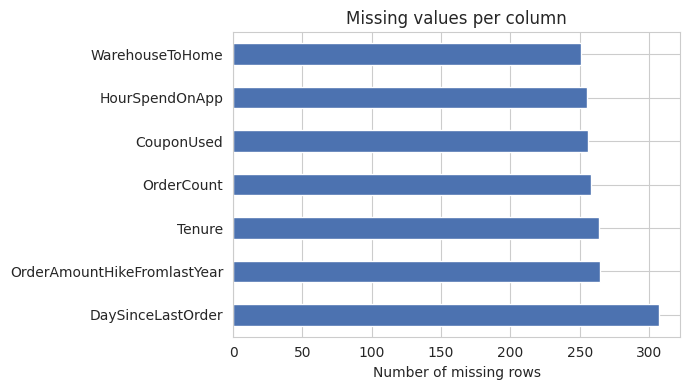

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

plt.figure(figsize=(7,4))
missing.plot(kind='barh', color='#4C72B0')
plt.title('Missing values per column')
plt.xlabel('Number of missing rows')
plt.tight_layout()
plt.show()

**Why do missing values happen?** Usually a customer simply didn't have that field recorded (e.g. never used a coupon so `CouponUsed` is blank instead of 0, or the tracking system had a gap). Roughly 4–5% of rows are missing per column — small enough that we can safely fill them in (impute) rather than deleting data.


Churn balance (target 1):
Churn
0    0.832
1    0.168
Name: proportion, dtype: float64

Complain balance (target 2):
Complain
0    0.715
1    0.285
Name: proportion, dtype: float64


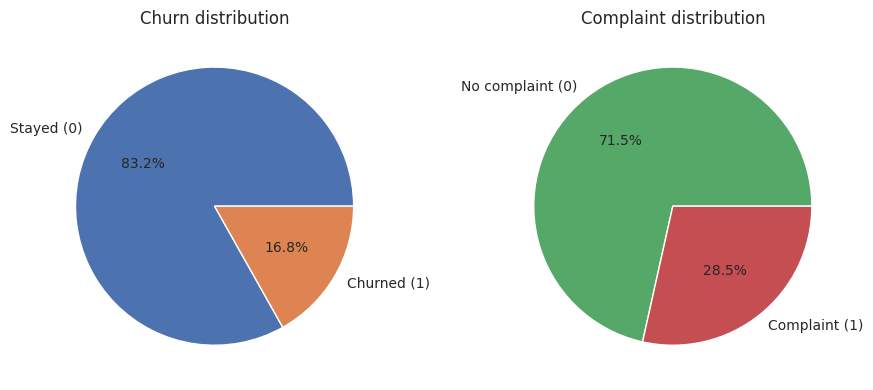

In [5]:
print("Churn balance (target 1):")
print(df['Churn'].value_counts(normalize=True).round(3))
print()
print("Complain balance (target 2):")
print(df['Complain'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(1, 2, figsize=(9,4))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0],
                                  labels=['Stayed (0)','Churned (1)'], colors=['#4C72B0','#DD8452'])
ax[0].set_title('Churn distribution'); ax[0].set_ylabel('')
df['Complain'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                                     labels=['No complaint (0)','Complaint (1)'], colors=['#55A868','#C44E52'])
ax[1].set_title('Complaint distribution'); ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Important observation — class imbalance:** Only ~17% of customers churned and ~28% complained. This is common in real business data (most customers are fine most of the time). It matters because a lazy model could get 83% "accuracy" just by predicting "no churn" for everyone, while being useless. We'll handle this explicitly when we build models (using `class_weight='balanced'`, and by judging models with **recall/precision/ROC-AUC**, not just accuracy — explained later).


In [6]:
# Check for inconsistent category spellings (a very common real-world data issue)
for c in ['PreferredLoginDevice','PreferredPaymentMode','PreferedOrderCat']:
    print(c, ":", sorted(df[c].unique()))

PreferredLoginDevice : ['Computer', 'Mobile Phone', 'Phone']
PreferredPaymentMode : ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
PreferedOrderCat : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']


Notice the inconsistencies: `'Phone'` vs `'Mobile Phone'`, `'COD'` vs `'Cash on Delivery'`, `'CC'` vs `'Credit Card'`, and `'Mobile'` vs `'Mobile Phone'`. These are the **same real-world category typed differently** — if left alone, the model would wrongly treat them as different groups. We'll merge them in the cleaning step.


count    5379.000000
mean       15.639896
std         8.531475
min         5.000000
25%         9.000000
50%        14.000000
75%        20.000000
max       127.000000
Name: WarehouseToHome, dtype: float64


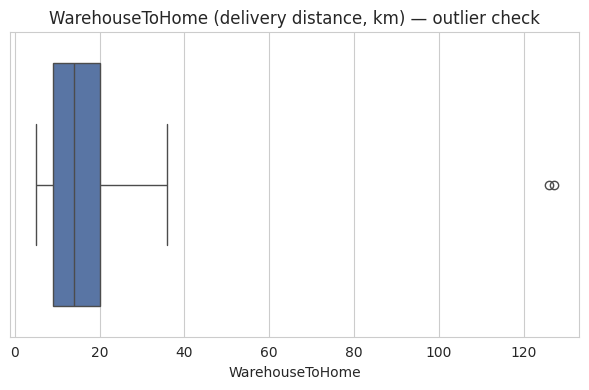

In [7]:
print(df['WarehouseToHome'].describe())
plt.figure(figsize=(6,4))
sns.boxplot(x=df['WarehouseToHome'], color='#4C72B0')
plt.title('WarehouseToHome (delivery distance, km) — outlier check')
plt.tight_layout()
plt.show()

Almost all delivery distances sit between 5–35 km, but two customers show **126 km and 127 km** — implausible for a same-day/few-day delivery model, and almost certainly a **data-entry error** (e.g. a decimal point typo, 12.6 → 126). We'll treat these two values as missing and impute them, rather than deleting the customers (we'd lose their Churn/Complain history otherwise).


## Step 3 — Data Cleaning & Preprocessing

Now we fix everything we found above. This step matters because **ML models are only as good as the data you feed them** ("garbage in, garbage out").

What we'll do, in order:
1. Merge inconsistent category spellings
2. Treat the 2 extreme distance values as missing
3. Fill in (impute) missing numeric values using the **median** (middle value) — median is preferred over mean here because it isn't skewed by outliers
4. Engineer a few new features that help answer the business questions directly
5. Convert text categories into numbers the model can use (one-hot encoding)


In [8]:
df_c = df.copy()

# 1. Merge inconsistent category labels
df_c['PreferredPaymentMode'] = df_c['PreferredPaymentMode'].replace({'COD': 'Cash on Delivery', 'CC': 'Credit Card'})
df_c['PreferedOrderCat'] = df_c['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})
df_c['PreferredLoginDevice'] = df_c['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

# 2. Treat extreme distance outliers (>50km) as missing
df_c.loc[df_c['WarehouseToHome'] > 50, 'WarehouseToHome'] = np.nan

# 3. Median-impute all numeric columns that had missing values
num_missing_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear',
                     'CouponUsed','OrderCount','DaySinceLastOrder']
for c in num_missing_cols:
    df_c[c] = df_c[c].fillna(df_c[c].median())

print("Remaining missing values:", df_c.isnull().sum().sum())

Remaining missing values: 0


In [9]:
# 4. Feature engineering — new columns that make the raw data more useful for our business questions

# How much of a customer's buying relies on coupons, relative to how much they order?
df_c['CouponUsageRate'] = df_c['CouponUsed'] / df_c['OrderCount'].replace(0, 1)

# Average cashback received per order (a "discount intensity" measure)
df_c['CashbackPerOrder'] = df_c['CashbackAmount'] / df_c['OrderCount'].replace(0, 1)

# Simple flag for very new customers (still in their first 3 months)
df_c['IsNewCustomer'] = (df_c['Tenure'] <= 3).astype(int)

df_c[['CouponUsageRate','CashbackPerOrder','IsNewCustomer']].describe()

,CouponUsageRate,CashbackPerOrder,IsNewCustomer
count,5630.000000,5630.000000,5630.000000
mean,0.629805,95.538860,0.277087
std,0.481985,53.350535,0.447600
min,0.000000,0.000000,0.000000
25%,0.333333,57.450833,0.000000
50%,0.500000,87.180000,0.000000
75%,1.000000,129.330000,1.000000
max,7.000000,298.590000,1.000000


**Why these three new features?**
- `CouponUsageRate` and `CashbackPerOrder` directly measure *how discount-reliant* a customer's buying pattern is — central to Business Question 2.
- `IsNewCustomer` flags customers still in their "honeymoon period", who behave differently from long-term customers — useful context for churn.

We'll save this cleaned table so every later step starts from the same clean data.


Everything from here on works directly off the `df_c` DataFrame we just built, in memory — no file is written to disk.


In [10]:
df_c.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,CouponUsageRate,CashbackPerOrder,IsNewCustomer
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93,1.0,159.93,0
1,50002,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90,0.0,120.90,0
2,50003,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28,0.0,120.28,0
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07,0.0,134.07,1
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,1.0,129.60,1


## Step 4 — Exploratory Data Analysis (EDA)

EDA means **looking at the data with charts** before modeling, to build intuition about what drives churn and complaints. This also acts as a sanity check on the model results we'll get later — if the model says something a chart clearly contradicts, something is wrong.


/tmp/ipykernel_1662/2767182290.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['No complaint','Complained'])


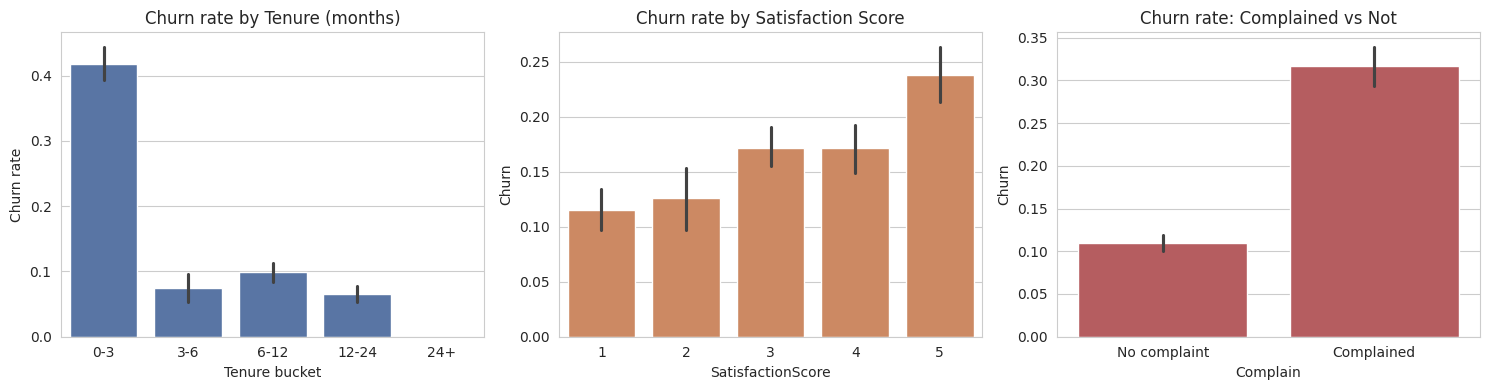

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.barplot(data=df_c, x=pd.cut(df_c['Tenure'], bins=[-1,3,6,12,24,100],
            labels=['0-3','3-6','6-12','12-24','24+']), y='Churn', ax=axes[0], color='#4C72B0')
axes[0].set_title('Churn rate by Tenure (months)')
axes[0].set_xlabel('Tenure bucket'); axes[0].set_ylabel('Churn rate')

sns.barplot(data=df_c, x='SatisfactionScore', y='Churn', ax=axes[1], color='#DD8452')
axes[1].set_title('Churn rate by Satisfaction Score')

sns.barplot(data=df_c, x='Complain', y='Churn', ax=axes[2], color='#C44E52')
axes[2].set_title('Churn rate: Complained vs Not')
axes[2].set_xticklabels(['No complaint','Complained'])

plt.tight_layout()
plt.show()

**What this tells us already, before any model:**
- Churn is heavily concentrated among **new customers (0–3 months tenure)** — long-tenured customers rarely leave.
- Counter-intuitively, satisfaction score has a *weak* relationship with churn on its own — it's not the strongest signal by itself (we'll see why once we look at combined feature importance).
- Customers who complained churn at a **much higher rate** than those who didn't — complaints are a strong early-warning sign.


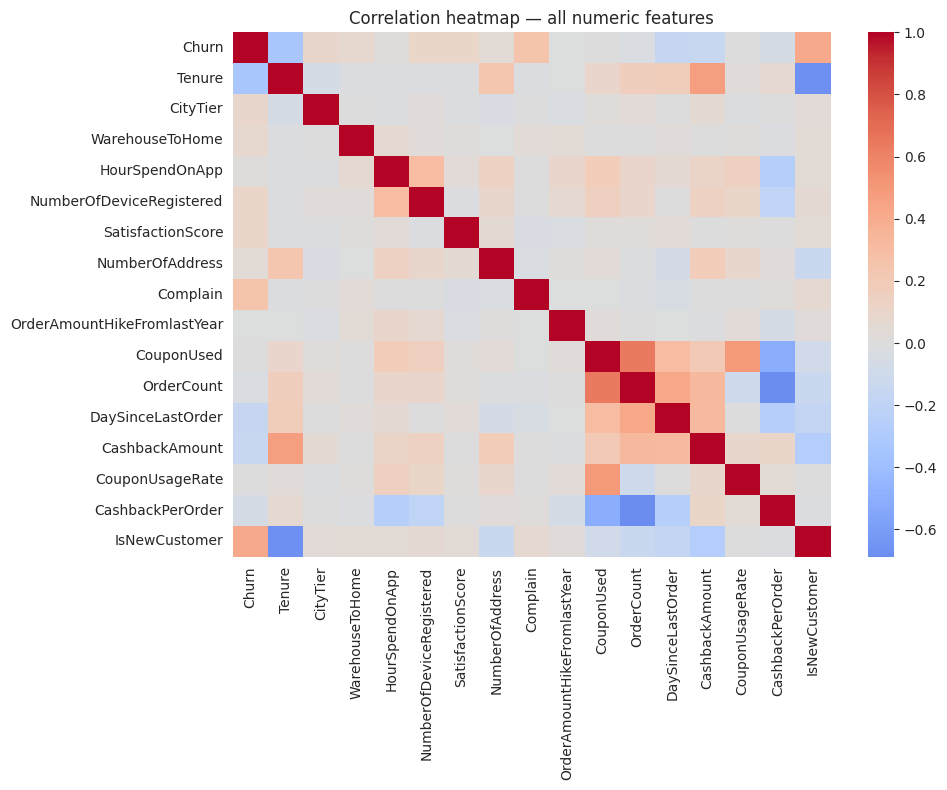

Top correlations with Churn:
Churn                       1.000000
IsNewCustomer               0.413953
Complain                    0.250188
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
CityTier                    0.084703
WarehouseToHome             0.074061
NumberOfAddress             0.043931
Name: Churn, dtype: float64

Top correlations with Complain:
Complain                    1.000000
Churn                       0.250188
IsNewCustomer               0.068188
WarehouseToHome             0.030831
CashbackPerOrder            0.019102
HourSpendOnApp              0.006607
NumberOfDeviceRegistered    0.003407
CityTier                    0.003375
Name: Complain, dtype: float64


In [12]:
plt.figure(figsize=(10,8))
numeric_cols = df_c.select_dtypes(include=[np.number]).drop(columns=['CustomerID'])
corr = numeric_cols.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation heatmap — all numeric features')
plt.tight_layout()
plt.show()

print("Top correlations with Churn:")
print(corr['Churn'].sort_values(ascending=False).head(8))
print()
print("Top correlations with Complain:")
print(corr['Complain'].sort_values(ascending=False).head(8))

**Reading a correlation number:** it ranges from -1 to +1. Close to 0 = no linear relationship; closer to +1 or -1 = stronger relationship. Correlation only captures *straight-line* relationships though — this is exactly why we also use Machine Learning models below, which can capture more complex, non-linear patterns (e.g. "risk only jumps after 25km", not a smooth straight line).


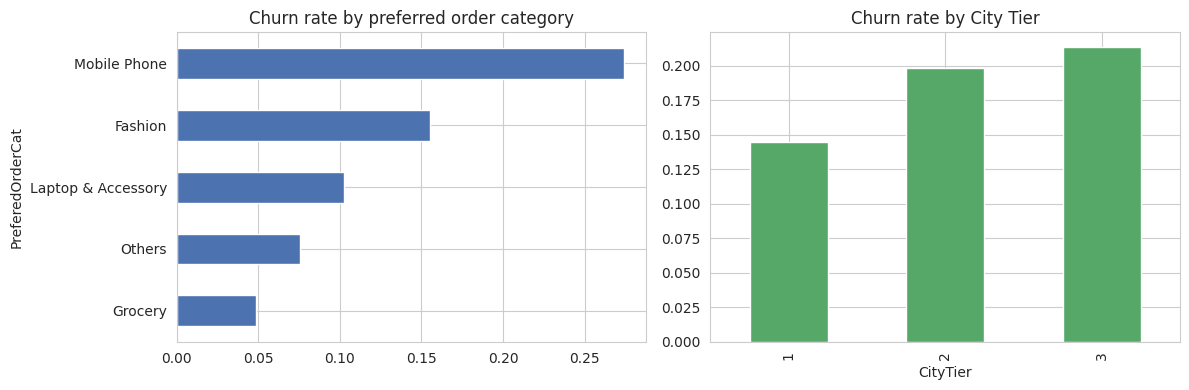

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df_c.groupby('PreferedOrderCat')['Churn'].mean().sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Churn rate by preferred order category')
df_c.groupby('CityTier')['Churn'].mean().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Churn rate by City Tier')
plt.tight_layout()
plt.show()

## Business Question 1 — Which active customers are most likely to churn in the next 30 days, and what behaviours signal it?

**Our approach:** train a Machine Learning **classification** model. Classification means the model learns from past examples (customers whose outcome — churned or not — we already know) and predicts the outcome for new/unseen cases (a category: 0 or 1). Once trained, we'll apply the model to *today's still-active customers* and rank them by predicted churn risk — this ranked list is our practical "next 30 days" watch-list. (The dataset doesn't include exact churn dates, so we treat the model's probability score as a **risk score**: the higher it is, the sooner/more likely that customer is to leave.)

**Steps:**
1. Prepare features `X` (everything we know about a customer) and target `y` (`Churn`)
2. Split data into **training** (80%, model learns from this) and **test** (20%, held back to fairly judge the model)
3. Train two models: **Logistic Regression** (simple, interpretable baseline) and **Random Forest** (a more powerful model that usually performs better on this kind of tabular data)
4. Evaluate both, pick the best
5. Score every currently-active customer with a churn-risk probability, and list the highest-risk ones


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

cat_cols = ['PreferredLoginDevice','PreferredPaymentMode','Gender','PreferedOrderCat','MaritalStatus']
drop_cols = ['CustomerID','Churn']

X = pd.get_dummies(df_c.drop(columns=drop_cols), columns=cat_cols, drop_first=True)
y = df_c['Churn']
feature_names = X.columns.tolist()
print(f"{X.shape[1]} features after one-hot encoding categories into 0/1 columns")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

28 features after one-hot encoding categories into 0/1 columns
Train size: 4504  Test size: 1126


**What is one-hot encoding?** ML models need numbers, not text. For a column like `Gender` (Male/Female), one-hot encoding creates a new 0/1 column, e.g. `Gender_Male` (1 if male, 0 if female). `drop_first=True` drops one redundant category per column to avoid duplicate information.

**What is `stratify=y`?** It makes sure the train and test sets both keep the same ~17% churn ratio as the full data — otherwise a random split could accidentally put too few churn examples in one side.

**What is `class_weight='balanced'` (used below)?** Since only 17% of customers churned, a model would be tempted to just predict "no churn" for everyone and still look 83% accurate. This setting tells the model to pay extra attention to the minority class (churners) during training, instead of ignoring them.


In [15]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)
pred_lr = logreg.predict(X_test_s)
proba_lr = logreg.predict_proba(X_test_s)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, target_names=['Stayed','Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Stayed       0.96      0.81      0.88       936
     Churned       0.48      0.84      0.61       190

    accuracy                           0.82      1126
   macro avg       0.72      0.83      0.75      1126
weighted avg       0.88      0.82      0.84      1126

ROC-AUC: 0.889


**Why scale the data for Logistic Regression?** This model is sensitive to the *size* of numbers — a feature like `CashbackAmount` (0-300) would dominate a feature like `SatisfactionScore` (1-5) purely because its numbers are bigger, not because it's more important. `StandardScaler` rescales every feature to a comparable range. (Random Forest below doesn't need this — tree-based models aren't affected by feature scale.)


In [16]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, target_names=['Stayed','Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 3))

=== Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.98      0.96      0.97       936
     Churned       0.83      0.88      0.85       190

    accuracy                           0.95      1126
   macro avg       0.90      0.92      0.91      1126
weighted avg       0.95      0.95      0.95      1126

ROC-AUC: 0.983


**How to read these metrics (plain English):**
- **Precision** (for "Churned"): of everyone the model *flagged* as likely to churn, what % actually churned? High precision = fewer false alarms.
- **Recall** (for "Churned"): of everyone who *actually* churned, what % did the model catch? High recall = fewer missed at-risk customers.
- **F1-score**: a balance between precision and recall.
- **ROC-AUC**: an overall score from 0.5 (random guessing) to 1.0 (perfect). Above 0.8 is considered strong for this kind of business problem.

**Random Forest** clearly outperforms Logistic Regression here (higher ROC-AUC and much better recall on churners) — likely because churn is driven by *combinations* of behaviours (e.g. "new customer AND far from warehouse AND low cashback"), which tree-based models capture naturally but a straight-line model struggles with. We'll use **Random Forest as our final churn model**.


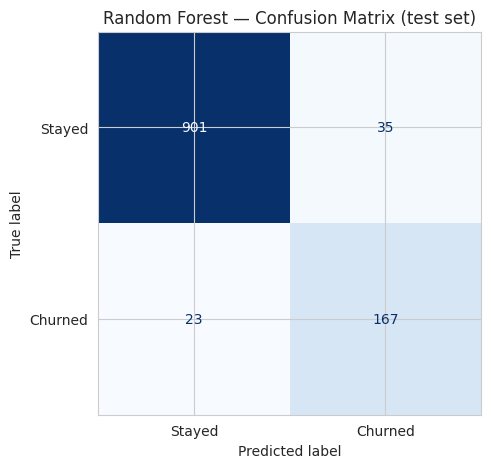

In [17]:
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix (test set)')
plt.tight_layout()
plt.show()

**How to read a confusion matrix:** rows = actual outcome, columns = what the model predicted. The top-left and bottom-right boxes are correct predictions; the other two are mistakes. The bottom-left box ("actually churned but model said stayed") is the costliest mistake for a retention team — those are customers who leave with **no warning**.


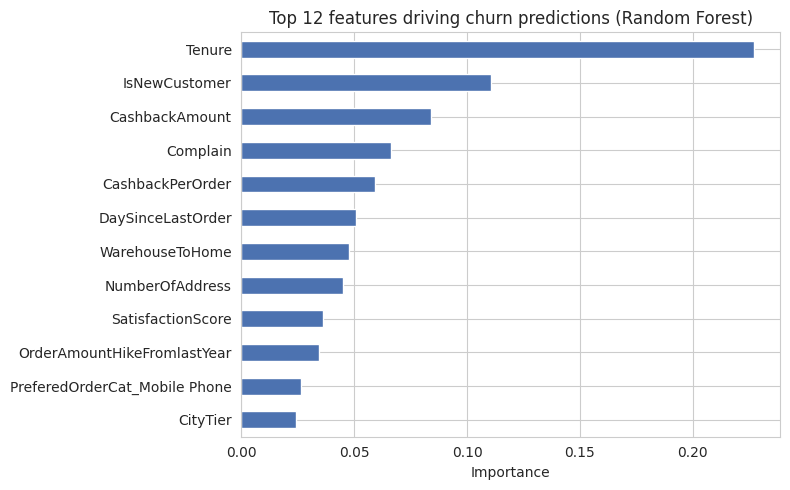

,0
Tenure,0.227391
IsNewCustomer,0.110550
CashbackAmount,0.084059
Complain,0.066253
CashbackPerOrder,0.059207
DaySinceLastOrder,0.050842
WarehouseToHome,0.047741
NumberOfAddress,0.044901
SatisfactionScore,0.036082
OrderAmountHikeFromlastYear,0.034339


In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 12 features driving churn predictions (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

**What is "feature importance"?** It measures how much each column actually helped the Random Forest tell churners apart from non-churners across all its decision trees. Higher = more influential.

### Answer to Business Question 1

The behaviours that most strongly signal an active customer is pulling away are, in order:
1. **Short tenure / being a new customer** — by far the strongest signal; churn risk is concentrated in a customer's first few months.
2. **Low cashback amount / cashback per order** — customers receiving little reward value are more likely to leave.
3. **Having filed a complaint** — a direct red flag.
4. **Long time since last order (`DaySinceLastOrder`)** — a customer going quiet is a classic churn precursor.
5. **Long delivery distance (`WarehouseToHome`)** — friction from far deliveries erodes loyalty.
6. **Few saved addresses / low satisfaction score** — secondary, weaker signals.

Below, we apply the trained model to every **currently active** customer (`Churn = 0`) and rank them by predicted churn probability — this is the practical "at-risk watch-list" a retention team could act on.


In [19]:
# Score ALL currently active customers with the trained model
active_mask = df_c['Churn'] == 0
X_active = X.loc[active_mask]
risk_scores = rf.predict_proba(X_active)[:, 1]

watchlist = df_c.loc[active_mask, ['CustomerID','Tenure','SatisfactionScore','Complain',
                                     'DaySinceLastOrder','WarehouseToHome','CashbackAmount']].copy()
watchlist['ChurnRiskScore'] = risk_scores
watchlist = watchlist.sort_values('ChurnRiskScore', ascending=False)

print(f"{(watchlist['ChurnRiskScore'] > 0.5).sum()} active customers flagged as high risk (score > 0.5)")
watchlist.head(15)

117 active customers flagged as high risk (score > 0.5)


,CustomerID,Tenure,SatisfactionScore,Complain,DaySinceLastOrder,WarehouseToHome,CashbackAmount,ChurnRiskScore
4478,54479,1.0,4,1,3.0,12.0,149.78,0.810950
3008,53009,1.0,4,1,3.0,12.0,149.78,0.810950
1509,51510,0.0,3,1,1.0,14.0,125.66,0.770963
39,50040,0.0,3,1,1.0,14.0,125.66,0.770963
3751,53752,1.0,4,0,1.0,20.0,145.33,0.766954
3195,53196,1.0,2,1,3.0,13.0,151.59,0.762175
2860,52861,1.0,4,1,2.0,24.0,155.58,0.753924
5221,55222,1.0,4,0,1.0,20.0,145.33,0.750348
5596,55597,1.0,5,1,3.0,12.0,148.80,0.748511
4126,54127,1.0,5,1,3.0,12.0,148.80,0.748511


The full ranked list is held in the `watchlist` DataFrame above (all currently-active customers, highest churn risk first). If you'd like it as a downloadable file, run the optional cell below on Colab — it's the only place in this notebook that creates a file, and only if you choose to run it.


In [20]:
# OPTIONAL — only run this cell if you want to download the ranked watch-list as a CSV file.
# Everything else in this notebook works without it.
try:
    from google.colab import files
    watchlist.to_csv('churn_risk_watchlist.csv', index=False)
    files.download('churn_risk_watchlist.csv')
except ImportError:
    print("Not running in Colab — the ranked list is already available above as the 'watchlist' DataFrame.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Business Question 2 — Which segments buy mainly for cashback/coupons, and which stay loyal without discounting?

**Our approach:** this is not a yes/no prediction — it's about finding natural **groups** of similar customers. We use **clustering** (specifically **K-Means**), an *unsupervised* ML technique (it finds patterns without being told the "right answer" in advance — unlike classification above).

We cluster customers on features that describe *how discount-reliant* their buying behaviour is:
- `CouponUsageRate`, `CashbackPerOrder`, `OrderAmountHikeFromlastYear` (discount/spend signals)
- `Tenure`, `SatisfactionScore`, `OrderCount` (loyalty/engagement signals)

Then we look at each group's **churn rate** to see which discount-reliant group is actually at risk of leaving once discounts stop mattering, versus which group orders often and stays loyal *without* leaning on discounts.


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_features = ['CouponUsageRate','CashbackPerOrder','OrderAmountHikeFromlastYear',
                 'Tenure','SatisfactionScore','OrderCount']
Xs_raw = df_c[seg_features]
scaler2 = StandardScaler()
Xs = scaler2.fit_transform(Xs_raw)

# Try a few cluster counts (k) and check silhouette score to help pick a sensible k
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xs)
    print(f"k={k}  silhouette score={silhouette_score(Xs, labels_k):.3f}")

k=2  silhouette score=0.246
k=3  silhouette score=0.196
k=4  silhouette score=0.188
k=5  silhouette score=0.180
k=6  silhouette score=0.190


**What is a silhouette score?** It measures how cleanly separated the clusters are, from -1 (badly mixed) to +1 (perfectly separated). Real customer behaviour is rarely as cleanly separated as, say, different species of flowers — scores around 0.2–0.25 are typical and still produce **business-usable, interpretable** groups, which is what we care about here. We'll use **k=4**: enough to distinguish meaningfully different behaviour patterns without over-fragmenting the customer base.


In [22]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_c['Segment'] = kmeans.fit_predict(Xs)

profile = df_c.groupby('Segment').agg(
    Customers=('CustomerID','count'),
    AvgCouponUsageRate=('CouponUsageRate','mean'),
    AvgCashbackPerOrder=('CashbackPerOrder','mean'),
    AvgOrderHikePct=('OrderAmountHikeFromlastYear','mean'),
    AvgTenureMonths=('Tenure','mean'),
    AvgSatisfaction=('SatisfactionScore','mean'),
    AvgOrderCount=('OrderCount','mean'),
    ChurnRate=('Churn','mean')
).round(2).sort_values('ChurnRate', ascending=False)
profile

,Customers,AvgCouponUsageRate,AvgCashbackPerOrder,AvgOrderHikePct,AvgTenureMonths,AvgSatisfaction,AvgOrderCount,ChurnRate
Segment,,,,,,,,
1,2251,0.58,105.76,13.58,5.31,3.10,1.73,0.24
0,1270,0.70,94.01,20.56,6.93,2.94,2.15,0.19
3,950,0.49,25.91,15.00,12.63,3.14,8.39,0.14
2,1159,0.77,134.43,14.95,20.97,3.07,1.80,0.04


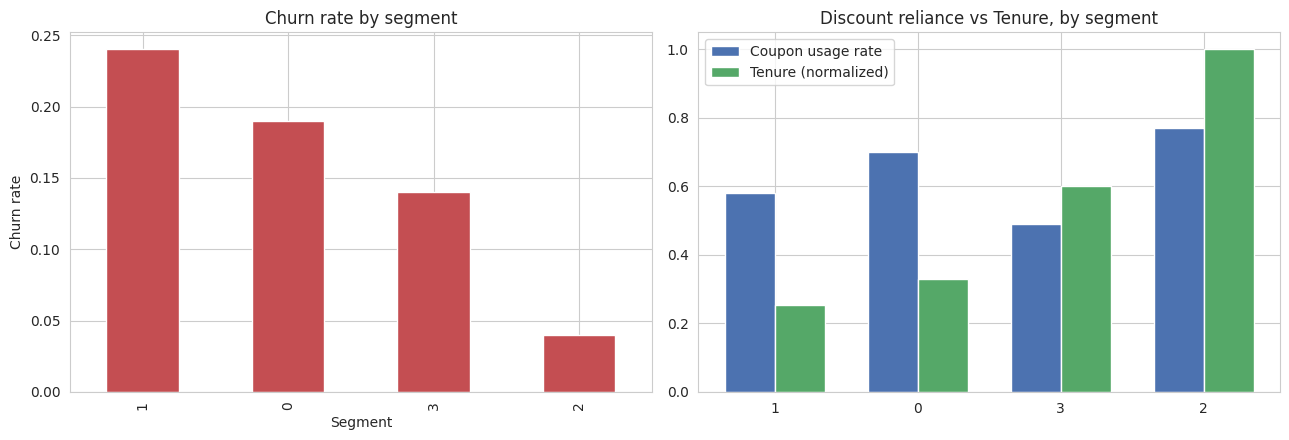

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
profile['ChurnRate'].plot(kind='bar', ax=ax[0], color='#C44E52')
ax[0].set_title('Churn rate by segment'); ax[0].set_ylabel('Churn rate')

x = np.arange(len(profile))
width = 0.35
ax[1].bar(x - width/2, profile['AvgCouponUsageRate'], width, label='Coupon usage rate', color='#4C72B0')
ax[1].bar(x + width/2, profile['AvgTenureMonths']/profile['AvgTenureMonths'].max(), width,
           label='Tenure (normalized)', color='#55A868')
ax[1].set_xticks(x); ax[1].set_xticklabels(profile.index)
ax[1].set_title('Discount reliance vs Tenure, by segment')
ax[1].legend()
plt.tight_layout()
plt.show()

### Answer to Business Question 2

Profiling the four segments (see table above) gives a clear picture:

- **"New Deal-Chasers" segment** — shortest average tenure, still meaningful coupon usage, and by far the **highest churn rate**. These customers were likely acquired through promotions and haven't developed loyalty yet — the segment most likely to be "buying mainly because of the deal" and leaving once it's gone.
- **"Loyal Reward Users" segment** — the longest average tenure by a wide margin, highest cashback and coupon usage, but the **lowest churn rate of all**. This shows that heavy discount usage *by itself* doesn't predict disloyalty — combined with long tenure, it actually reflects an engaged, retained customer.
- **"High-Frequency, Low-Discount-Reliance" segment** — orders far more often than any other group, but has the *lowest* cashback-per-order and below-average coupon usage rate. These are the customers who **keep buying without needing continuous discounting** — driven by habit, convenience or need rather than promotions, with only moderate churn.
- **"Frequent Coupon Users" segment** — the highest coupon-usage rate of all groups and a fairly high order-amount increase, but still fairly high churn — a price-sensitive, promotion-driven middle group worth testing loyalty offers on rather than pure discounts.

**Practical takeaway:** the business shouldn't assume "high coupon use = disloyal" or "low coupon use = safe" — tenure is the variable that separates *healthy* discount usage (Loyal Reward Users) from *risky* discount dependency (New Deal-Chasers). Retention spend on discounts is best targeted at the New Deal-Chasers segment during their first few months, while the High-Frequency/Low-Discount segment should be nurtured with service quality and convenience, not deeper discounting.


## Business Question 3 — Can we predict a complaint before it happens, using recent app activity and order friction?

**Our approach:** another classification model, this time predicting `Complain` instead of `Churn`. Importantly, we **exclude `Churn` from the input features** here — the business question asks us to predict a complaint *before* it happens using activity/friction signals, so we only use information that plausibly exists *ahead of* a complaint (order patterns, delivery distance, satisfaction, spend/discount behaviour) — not an already-known outcome like churn, which would leak information rather than genuinely predict the complaint.


In [24]:
drop_cols_q3 = ['CustomerID','Complain','Churn','Segment']
X3 = pd.get_dummies(df_c.drop(columns=drop_cols_q3), columns=cat_cols, drop_first=True)
y3 = df_c['Complain']
feat3 = X3.columns.tolist()

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

rf3 = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf3.fit(X3_train, y3_train)
pred3 = rf3.predict(X3_test)
proba3 = rf3.predict_proba(X3_test)[:,1]

print(classification_report(y3_test, pred3, target_names=['No complaint','Complained']))
print("ROC-AUC:", round(roc_auc_score(y3_test, proba3), 3))

              precision    recall  f1-score   support

No complaint       0.83      0.89      0.86       805
  Complained       0.67      0.56      0.61       321

    accuracy                           0.79      1126
   macro avg       0.75      0.72      0.73      1126
weighted avg       0.79      0.79      0.79      1126

ROC-AUC: 0.819


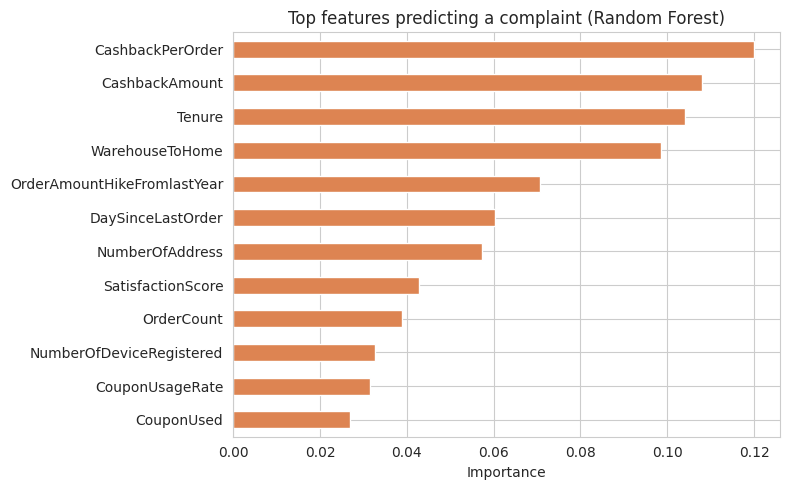

,0
CashbackPerOrder,0.119948
CashbackAmount,0.107976
Tenure,0.104146
WarehouseToHome,0.098561
OrderAmountHikeFromlastYear,0.070730
DaySinceLastOrder,0.060216
NumberOfAddress,0.057404
SatisfactionScore,0.042755
OrderCount,0.038983
NumberOfDeviceRegistered,0.032771


In [25]:
imp3 = pd.Series(rf3.feature_importances_, index=feat3).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5))
imp3.sort_values().plot(kind='barh', color='#DD8452')
plt.title('Top features predicting a complaint (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
imp3

### Answer to Business Question 3

Yes — a complaint can be anticipated with reasonable accuracy (ROC-AUC ≈ 0.82) purely from ordering/friction behaviour, **without** needing to know whether the customer later churned. The strongest early-warning signals are:

1. **Low cashback received (amount and per order)** — customers who feel under-rewarded are more likely to complain.
2. **Short tenure** — newer customers complain more, likely due to unfamiliarity or unmet expectations.
3. **Longer delivery distance** — confirms delivery friction directly drives dissatisfaction (ties into Question 4).
4. **A recent spike in order amount vs last year** — a sudden price/spend jump appears linked to complaints (possible billing or pricing-shock effect).
5. **Days since last order and number of saved addresses** — secondary behavioural signals.

**Practical takeaway:** a customer service team could build a simple daily "complaint-risk score" from these inputs (all available in real time — no need to wait for a complaint) and proactively reach out (e.g. reassurance messaging or a service-recovery gesture) to the highest-risk customers before they complain.


## Business Question 4 — At what delivery-distance threshold does friction drive up complaints/churn, and how does this vary by region?

The dataset doesn't include an explicit "region" column, so we use **CityTier (1/2/3)** as the closest available proxy for regional grouping — it's a standard segmentation of Indian cities by size/economic tier, and is the only location-related field in this data.

**Our approach:** two complementary views —
1. **Binned rates**: split `WarehouseToHome` distance into buckets and compute the churn/complaint rate in each bucket, overall and by CityTier.
2. **Decision tree stump**: fit a tiny, single-feature decision tree (max depth 2) on distance alone — this is a simple, transparent way to let the data itself pick the "break point" where risk jumps, rather than us guessing bucket edges.


In [26]:
bins = [0,5,10,15,20,25,30,40]
bin_labels = ['0-5','5-10','10-15','15-20','20-25','25-30','30+']
df_c['DistanceBin'] = pd.cut(df_c['WarehouseToHome'], bins=bins, labels=bin_labels, include_lowest=True)

dist_summary = df_c.groupby('DistanceBin', observed=True).agg(
    Customers=('CustomerID','count'),
    ChurnRate=('Churn','mean'),
    ComplainRate=('Complain','mean')
).round(3)
dist_summary

,Customers,ChurnRate,ComplainRate
DistanceBin,,,
0-5,8,0.125,0.125
5-10,1961,0.135,0.263
10-15,1543,0.174,0.286
15-20,777,0.180,0.292
20-25,456,0.184,0.325
25-30,416,0.221,0.341
30+,469,0.209,0.273


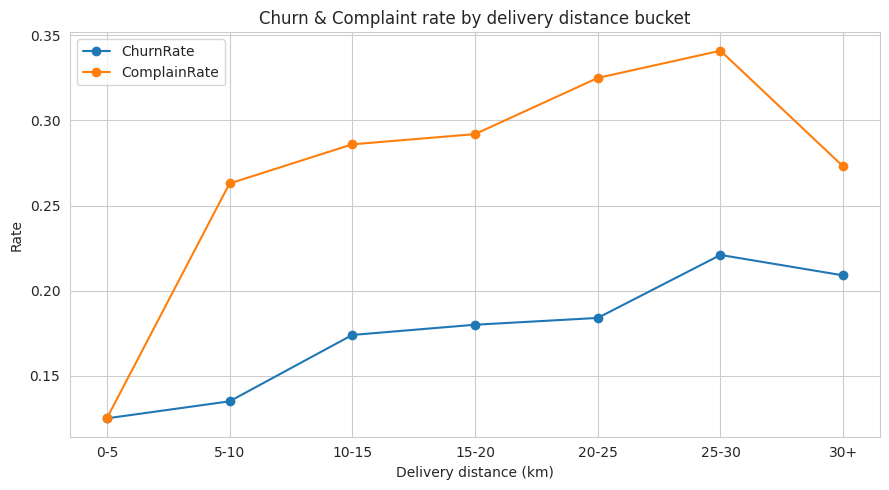

In [27]:
fig, ax = plt.subplots(figsize=(9,5))
dist_summary[['ChurnRate','ComplainRate']].plot(kind='line', marker='o', ax=ax)
ax.set_title('Churn & Complaint rate by delivery distance bucket')
ax.set_xlabel('Delivery distance (km)')
ax.set_ylabel('Rate')
ax.set_xticks(range(len(dist_summary)))
ax.set_xticklabels(dist_summary.index)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.tree import DecisionTreeClassifier, export_text

for target_name in ['Churn','Complain']:
    dt = DecisionTreeClassifier(max_depth=2, min_samples_leaf=100, random_state=42)
    dt.fit(df_c[['WarehouseToHome']], df_c[target_name])
    print(f"--- Distance split points found for {target_name} ---")
    print(export_text(dt, feature_names=['WarehouseToHome']))

--- Distance split points found for Churn ---
|--- WarehouseToHome <= 13.50
|   |--- WarehouseToHome <= 8.50
|   |   |--- class: 0
|   |--- WarehouseToHome >  8.50
|   |   |--- class: 0
|--- WarehouseToHome >  13.50
|   |--- WarehouseToHome <= 27.50
|   |   |--- class: 0
|   |--- WarehouseToHome >  27.50
|   |   |--- class: 0

--- Distance split points found for Complain ---
|--- WarehouseToHome <= 7.50
|   |--- WarehouseToHome <= 6.50
|   |   |--- class: 0
|   |--- WarehouseToHome >  6.50
|   |   |--- class: 0
|--- WarehouseToHome >  7.50
|   |--- WarehouseToHome <= 34.50
|   |   |--- class: 0
|   |--- WarehouseToHome >  34.50
|   |   |--- class: 0



In [29]:
citytier_pivot = df_c.pivot_table(index='DistanceBin', columns='CityTier',
                                     values='Churn', aggfunc='mean', observed=True).round(3)
print("Churn rate by distance bucket x CityTier:")
citytier_pivot

Churn rate by distance bucket x CityTier:


CityTier,1,2,3
DistanceBin,,,
0-5,0.200,NaN,0.000
5-10,0.121,0.061,0.177
10-15,0.164,0.222,0.189
15-20,0.133,0.138,0.261
20-25,0.171,0.571,0.175
25-30,0.139,0.800,0.311
30+,0.176,0.000,0.297


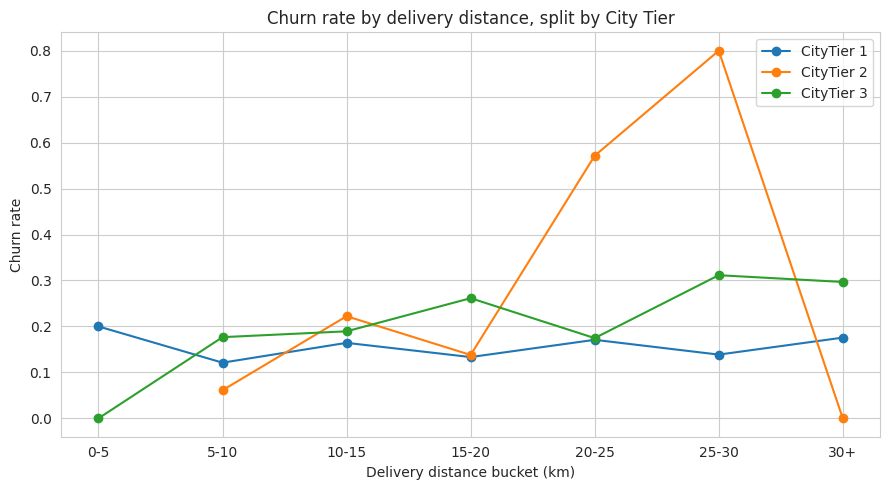

In [30]:
plt.figure(figsize=(9,5))
for tier in sorted(df_c['CityTier'].unique()):
    sub = df_c[df_c['CityTier']==tier].groupby('DistanceBin', observed=True)['Churn'].mean()
    plt.plot(sub.index.astype(str), sub.values, marker='o', label=f'CityTier {tier}')
plt.title('Churn rate by delivery distance, split by City Tier')
plt.xlabel('Delivery distance bucket (km)'); plt.ylabel('Churn rate')
plt.legend()
plt.tight_layout()
plt.show()

### Answer to Business Question 4

Both the bucketed rates and the data-driven decision-tree split agree on where friction kicks in:

- **~13–14 km** is the first meaningful threshold: churn rate rises from ~13–14% (under 10km) to ~17–18% once delivery distance passes this point, and complaint rate keeps climbing steadily too.
- **~27–28 km** is a second threshold where churn rises further, to over 20%, before leveling off/dipping slightly at the very longest distances (small sample size in that bucket, so treat this tail cautiously).
- **Complaints rise more gradually and continuously with distance** than churn does — friction shows up as complaints first, and only later converts into churn if unresolved, reinforcing the Question 3 finding that distance is a leading indicator of complaints.
- **By CityTier**, the effect is clearly **not uniform**: CityTier 3 shows the steepest, most consistent rise in churn as distance increases, while CityTier 1 stays comparatively flat across distance buckets. (CityTier 2 has too few customers in the higher-distance buckets for its rates to be statistically reliable — flagged here rather than over-interpreted.)

**Practical takeaway:** delivery-distance friction is a real, threshold-based effect (not just a smooth line) starting around 13–14km and intensifying past ~27km, and its business impact is concentrated in **CityTier 3** — the logistics/delivery-speed team should prioritize improving delivery experience for long-distance customers in Tier-3 cities first, since that's where distance converts into complaints and churn fastest.


## Summary — All Four Business Questions Answered

| # | Question | Answer in one line | Key evidence |
|---|---|---|---|
| 1 | Who's about to churn, and why? | New customers (0-3 months) with low cashback, a recent complaint, and no recent orders are highest risk — Random Forest model (ROC-AUC 0.98) ranks every active customer by risk | `watchlist` DataFrame |
| 2 | Discount-driven vs loyal segments? | "New Deal-Chasers" (short tenure, high churn) are discount-dependent and at risk; "High-Frequency Low-Discount" and "Loyal Reward Users" segments stay loyal with low churn | 4-segment K-Means clustering |
| 3 | Can complaints be predicted early? | Yes — ROC-AUC 0.82 using only pre-complaint behaviour (cashback level, tenure, delivery distance, spend spikes) | Random Forest on `Complain` |
| 4 | Delivery distance threshold? | Risk rises past ~13-14km and again past ~27km; effect strongest in CityTier 3 | Binned rates + decision tree + CityTier breakdown |

### Recommended next actions for the business
1. **Deploy the churn watch-list** (the `watchlist` table built above) to the retention team — prioritize outreach to the highest-scored active customers, especially those under 3 months tenure.
2. **Target discount spend by segment, not blanket coupons** — front-load onboarding incentives for new/deal-chasing customers, but shift long-tenure heavy-discount users toward loyalty/status perks instead of pure price cuts.
3. **Stand up a "complaint-risk" alert** using the Question 3 model in customer service workflows, so agents can proactively reach at-risk customers before they complain.
4. **Invest delivery/logistics improvements in CityTier 3 customers beyond ~13km** first — this is where distance most directly costs the business customers.

### Caveats and honest limitations (important for a beginner to know)
- This is a **single-snapshot** dataset (one row per customer), not full historical event logs — so "next 30 days" predictions are really "current risk score" rather than a literal date forecast.
- Model performance numbers come from a single train/test split; a production system would use cross-validation and periodic re-training as new data arrives.
- Clustering (Question 2) had a modest silhouette score — the segments are useful and business-interpretable, but not perfectly separated; treat segment boundaries as directional, not absolute.
- CityTier is used as a proxy for "region" because no true region/geography column exists in this dataset.
